# Часть 1

## Этап 1

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import mlflow
import os
from dotenv import load_dotenv
import utils

load_dotenv()

TRACKING_SERVER_HOST = os.environ['TRACKING_SERVER_HOST']
TRACKING_SERVER_PORT = os.environ['TRACKING_SERVER_PORT']
MLFLOW_TRACKING_URI = f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"

EXPERIMENT_NAME = os.environ['EXPERIMENT_NAME']
RUN_NAME = 'eda_research'

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_registry_uri(MLFLOW_TRACKING_URI)

/home/mle-user/mle_projects/mle-uplift-yeda/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('uplift_fp_data.csv')

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


In [5]:
print("nans by columns")
for col in df.columns:
    print(f"{col}: {df[col].isna().sum()} {df[col].isnull().sum()}")

nans by columns
recency: 0 0
history_segment: 0 0
history: 0 0
mens: 0 0
womens: 0 0
zip_code: 0 0
newbie: 0 0
channel: 0 0
treatment: 0 0
target: 0 0


In [114]:
print("Уникальные значения для дискретных колонок")
for col in ['history_segment', 'mens', 'womens', 'zip_code', 'newbie', 'channel']:
    print(f"{col}: {df[col].unique()}")

Уникальные значения для дискретных колонок
history_segment: [1 2 4 0 5 3 6]
mens: [1 0]
womens: [0 1]
zip_code: [1 2 0]
newbie: [0 1]
channel: [1 2 0]


В исходном датасете нет пропусков и все данные чистые

## Этап 2

### EDA


In [5]:
ASSETS_DIR = 'eda_assets'

sns.set_palette('muted')

Размер тестовой и контрольной групп

In [6]:
df.groupby('treatment').size()

treatment
0    42613
1    21387
dtype: int64

Количество целевых записей

In [18]:
df.groupby('target').size()

target
0    54606
1     9394
dtype: int64

Распределение таргета по группам

In [20]:
df.groupby(['target', 'treatment']).size().reset_index()

,target,treatment,0
0,0,0,36457
1,0,1,18149
2,1,0,6156
3,1,1,3238


Проверяем баланс групп по каждому признаку

In [ ]:
def check_balance(df, features, treatment_col='treatment'):
    balance_report = []
    for col in features:
        if df[col].nunique() <= 5:
            stats = df.groupby(treatment_col)[col].value_counts(normalize=True).unstack()
        else:
            stats = df.groupby(treatment_col)[col].mean()
        print(f"--- Balance for {col} ---")
        print(stats)
        print("\n")

features = ['recency', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
check_balance(df, features)

--- Balance for recency ---
treatment
0    5.761669
1    5.767850
Name: recency, dtype: float64


--- Balance for history ---
treatment
0    241.859315
1    242.536633
Name: history, dtype: float64


--- Balance for mens ---
mens              0         1
treatment                    
0          0.447915  0.552085
1          0.451068  0.548932


--- Balance for womens ---
womens            0         1
treatment                    
0          0.450473  0.549527
1          0.449899  0.550101


--- Balance for zip_code ---
zip_code          0         1         2
treatment                              
0          0.401403  0.448830  0.149767
1          0.400056  0.451209  0.148735


--- Balance for newbie ---
newbie            0         1
treatment                    
0          0.498252  0.501748
1          0.496750  0.503250


--- Balance for channel ---
channel           0         1         2
treatment                              
0          0.121630  0.435712  0.442658
1          0.120

Заметен небольшой дисбаланс в размерах тестовой и контрольной группы и целевых действий в этих группах

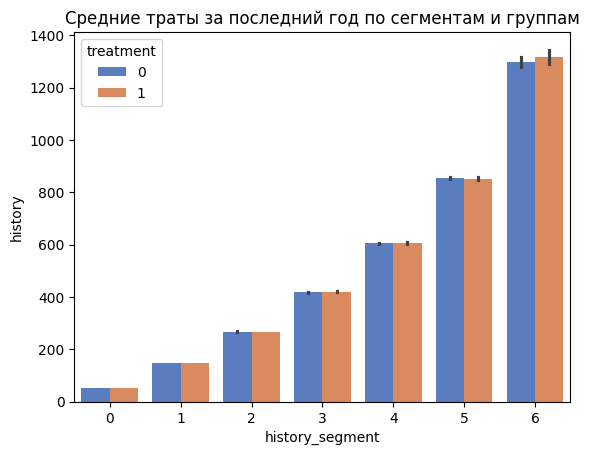

In [65]:
sns.barplot(
    df,
    x='history_segment',
    y='history',
    hue='treatment',
    estimator='mean'
)

plt.title("Средние траты за последний год по сегментам и группам")

plt.savefig(f"{ASSETS_DIR}/mean_history_by_segments.png")

Несмотря на дисбаланс в размере группы разделены равномерно

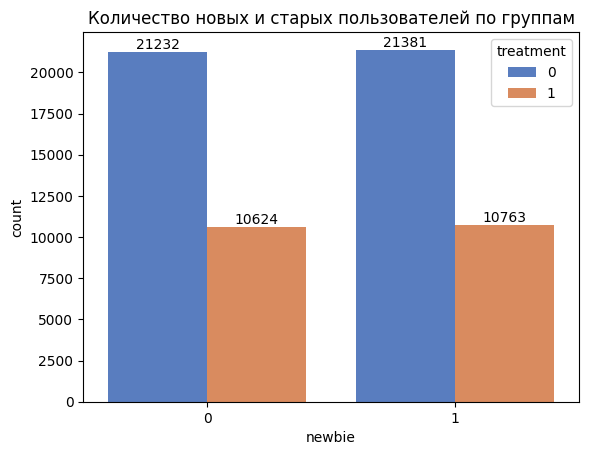

In [66]:
agg = df.groupby(['newbie', 'treatment']).size().reset_index().rename(columns={0: 'count'})

ax = sns.barplot(
    agg,
    x='newbie',
    y='count',
    hue='treatment'
)
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Количество новых и старых пользователей по группам")

plt.savefig(f"{ASSETS_DIR}/newbie_distribution.png")

In [4]:
test = df[df['treatment'] == 1]
control = df[df['treatment'] == 0]

Сравнение уровня uplift по сегментам

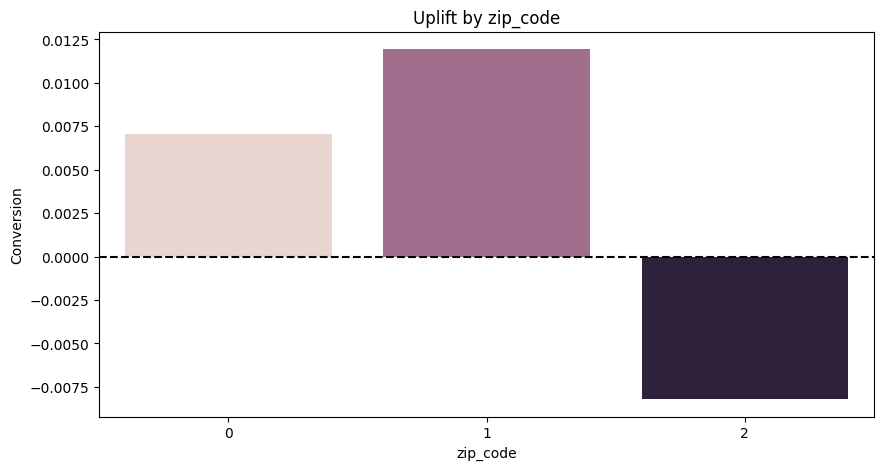

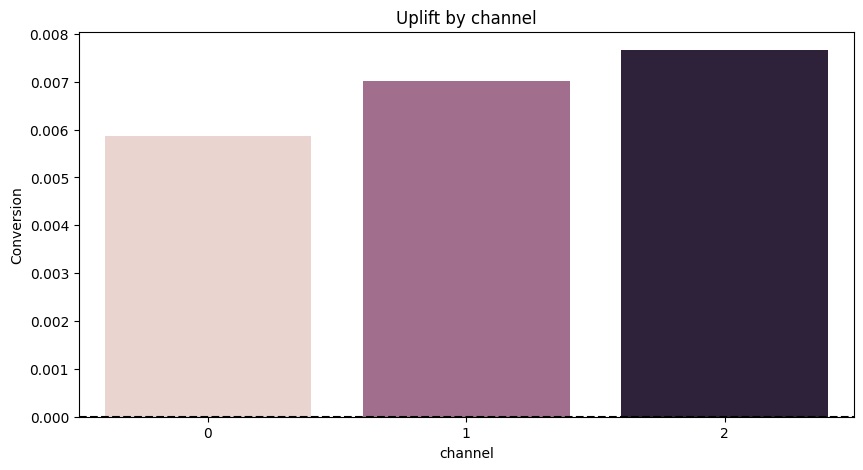

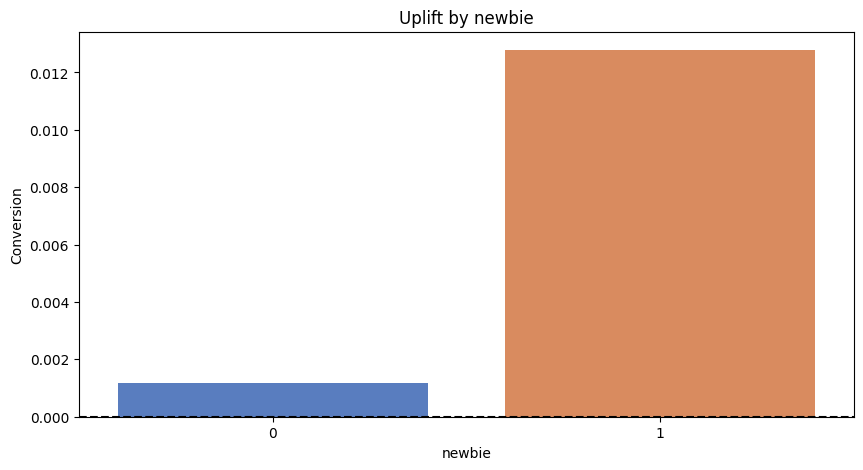

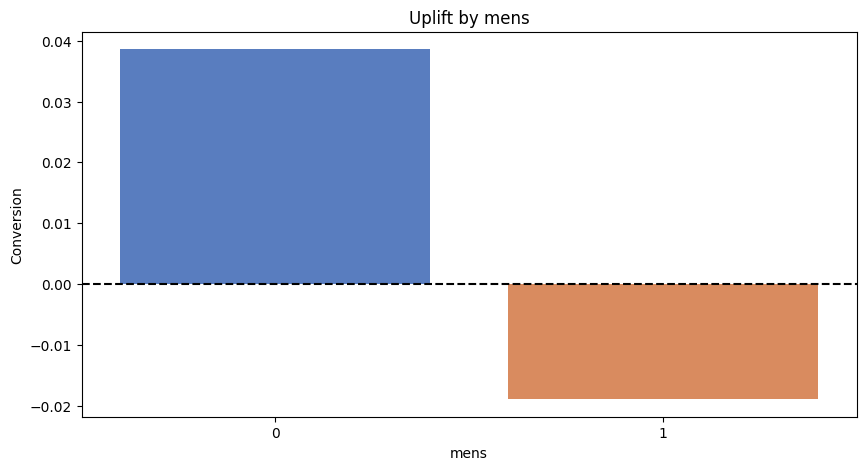

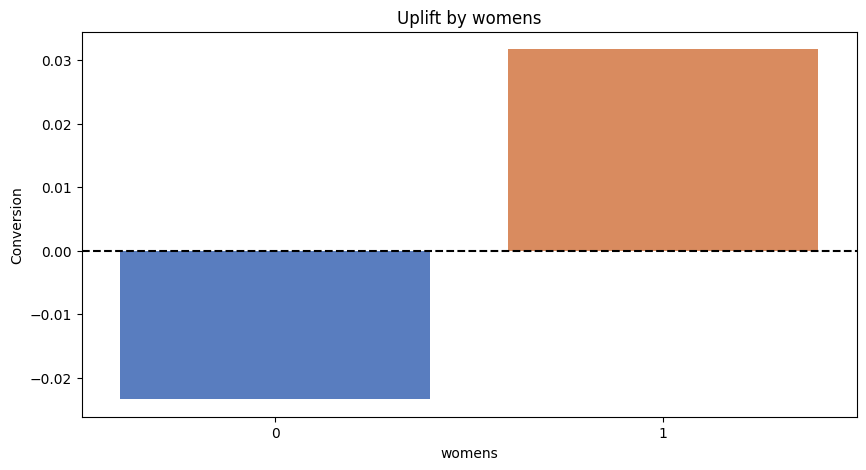

In [70]:
def plot_uplift_by_category(df, col, treatment_col='treatment', target_col='target'):
    summary = df.groupby([col, treatment_col])[target_col].agg(['mean', 'std', 'count']).reset_index()
    
    pivot = summary.pivot(index=col, columns=treatment_col, values='mean')
    uplift = pivot[1] - pivot[0]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=uplift.index, y=uplift.values, hue=uplift.index, legend=False, errorbar='ci')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f'Uplift by {col}')
    plt.ylabel('Conversion')

    plt.savefig(f"{ASSETS_DIR}/uplift_by_{col}.png")

    plt.show()

for cat_col in ['zip_code', 'channel', 'newbie', 'mens', 'womens']:
    plot_uplift_by_category(df, cat_col)

Сравнение конверсии групп для непрерывных переменных

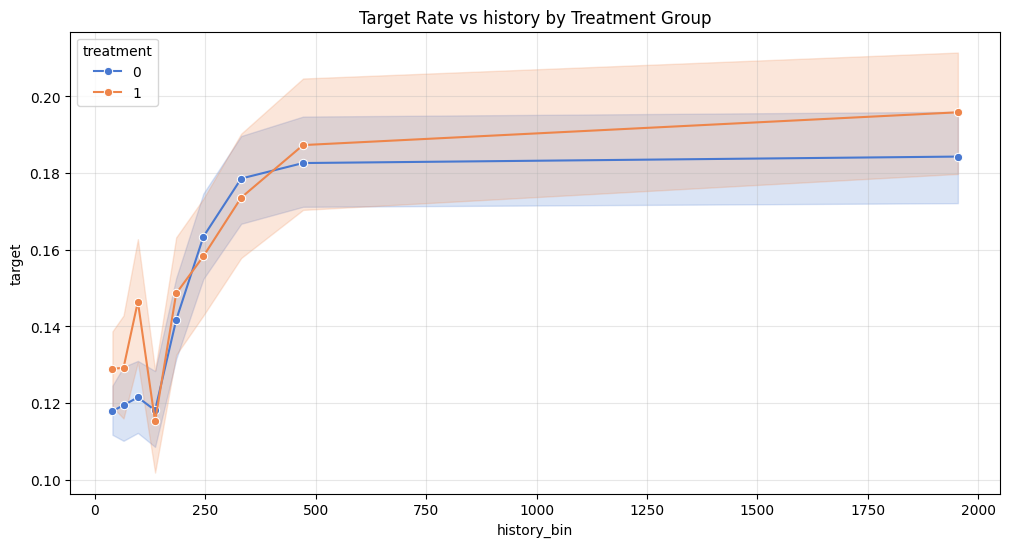

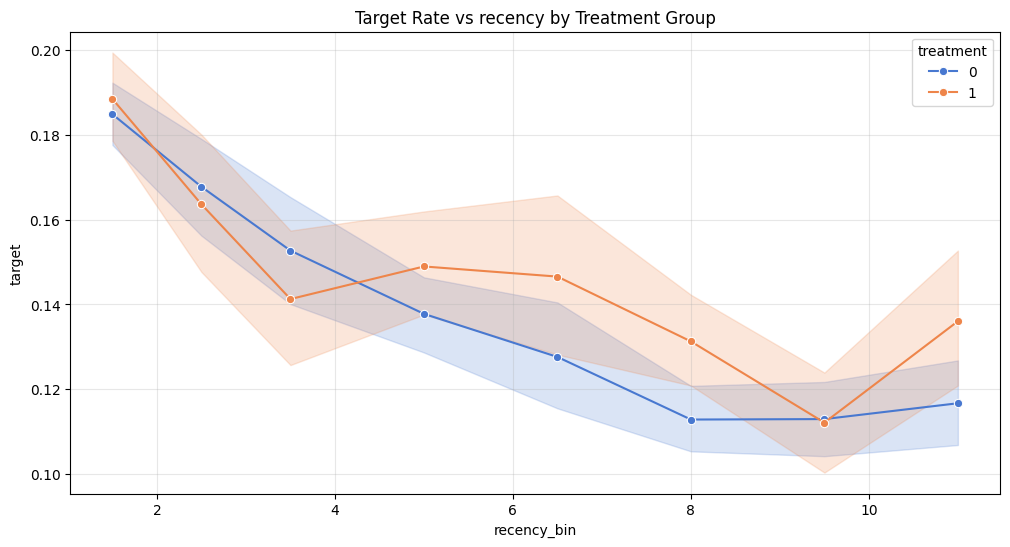

In [28]:
def plot_interaction(df, col, bins=10):
    df_temp = df.copy()
    df_temp[f'{col}_bin'] = pd.qcut(df[col], q=bins, duplicates='drop').apply(lambda x: x.mid)
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_temp, x=f'{col}_bin', y='target', hue='treatment', marker='o')
    plt.title(f'Target Rate vs {col} by Treatment Group')
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{ASSETS_DIR}/target_rate_{col}.png")
    plt.show()

plot_interaction(df, 'history')
plot_interaction(df, 'recency')

По ценовым сегментам скидка дает сильно положительный эффект в первых трех бинах. В следующих прослеживается отрицательный эффект за исключением последнего

Положительный uplift прослеживается в группе пользователей с 5-9 месяцами с последней покупки. Так же эффектр продолжает расти и после 10 месяцев отсутствия активности

Propensity Score AUC: 0.5495


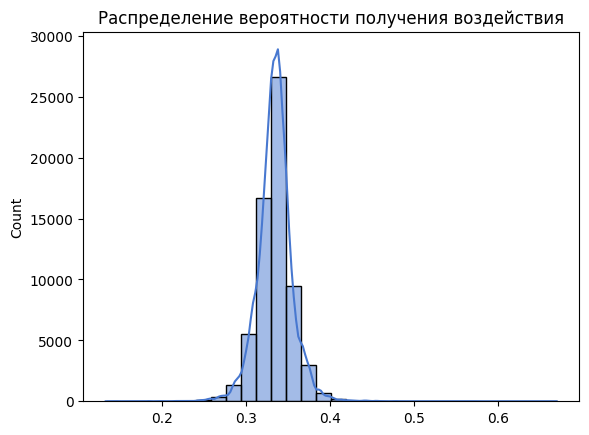

In [73]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

X_p = df.drop(['target', 'treatment', 'history_segment'], axis=1)
y_p = df['treatment']

prop_model = XGBClassifier(n_estimators=50, max_depth=3)
prop_model.fit(X_p, y_p)

preds = prop_model.predict_proba(X_p)[:, 1]
auc = roc_auc_score(y_p, preds)

print(f"Propensity Score AUC: {auc:.4f}")

sns.histplot(preds, bins=30, kde=True)
plt.title("Распределение вероятности получения воздействия")
plt.savefig(f"{ASSETS_DIR}/treatment_propensity_distribution.png")
plt.show()

In [29]:
experiment_id = mlflow.set_experiment(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name='eda_research', experiment_id=experiment_id) as run:
    mlflow.log_artifacts(ASSETS_DIR)
    mlflow.log_artifact('uplift_project.ipynb')

🏃 View run eda_research at: http://127.0.0.1:5000/#/experiments/7/runs/10d8a998fe6744f5b2ff4577c1aafca3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


### Вывод на основе EDA
1. В объеме данных нет сильного дисбаланса по количеству записей, а по признакам группы распределены идеально
2. Выдача промокода сильно снижает конверсию в группе с мужскими товарами, а так же в селах (с индексом 2)
3. Для новых пользователей конверсия сильно выше (в 12 раз), чем для старых пользователей. Для старых пользователей она находится на очень низком уровне
4. Выдача промокода дает наибольший эффект в ценовой группе до 150$ и некоторый эффект после 500$. В промежутке от 150 до 500 она оказывает скорее отрицательное воздействие
5. Промокод вызывает положительную конверсию у пользователей с периодом последней активности 5-9 месяцев и больше 10 месяцев. Лучший вариант 7 месяцев
6. Рандомизация воздействий по сегментам почти идеальная, что показывает значение AUC около 0.5

# Этап 2

### Проверка на статистическую значимость

In [6]:
test = df[df['treatment'] == 1]['target']
control = df[df['treatment'] == 0]['target']

Расчет статистик

In [19]:
stats = df.groupby('treatment')['target'].agg(['mean', 'std', 'count'])
print(stats)

               mean       std  count
treatment                           
0          0.144463  0.351563  42613
1          0.151400  0.358447  21387


Распределение 

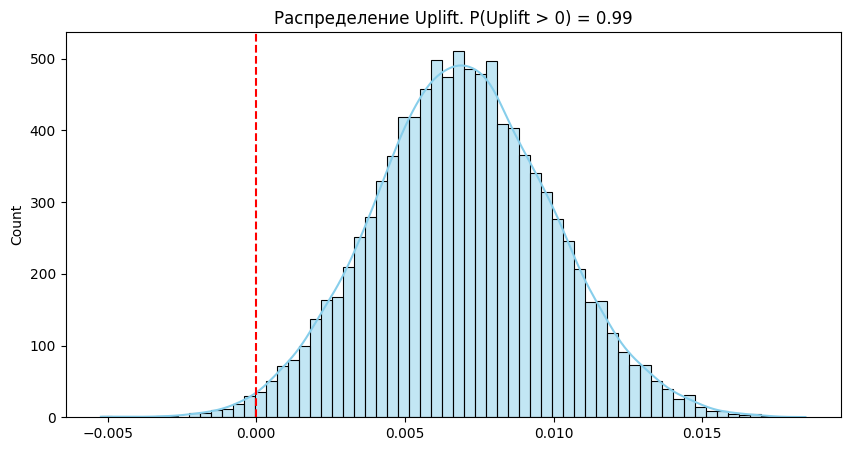

In [ ]:
def bootstrap_uplift(test_data, control_data, n_iterations=10000):
    boot_uplifts = []
    for _ in range(n_iterations):
        sample_t = np.random.choice(test_data, size=len(test_data), replace=True)
        sample_c = np.random.choice(control_data, size=len(control_data), replace=True)
        boot_uplifts.append(np.mean(sample_t) - np.mean(sample_c))
    return np.array(boot_uplifts)

boot_results = bootstrap_uplift(test['target'].values, control['target'].values)

# Вероятность того, что uplift > 0
prob_positive = (boot_results > 0).mean()

plt.figure(figsize=(10, 5))
sns.histplot(boot_results, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.title(f"Распределение Uplift. P(Uplift > 0) = {prob_positive:.2f}")
plt.show()

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

counts = np.array([test['target'].sum(), control['target'].sum()])
nobs = np.array([len(test), len(control)])

z_stat, p_val = proportions_ztest(counts, nobs, alternative='two-sided')

print(f"Z-score: {z_stat:.4f}")
print(f"p-value: {p_val:.4f}")

Z-score: 2.3393
p-value: 0.0193


In [ ]:
import scipy.stats as stats

p1 = test['target'].mean()
p2 = control['target'].mean()
n1 = len(test)
n2 = len(control)

se = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)

diff = p1 - p2
conf_interval = (diff - 1.96 * se, diff + 1.96 * se)

print(f"Uplift (Разница конверсий): {diff:.4f}")
print(f"95% Доверительный интервал: ({conf_interval[0]:.4f}, {conf_interval[1]:.4f})")

Uplift (Разница конверсий): 0.0069
95% Доверительный интервал: (0.0011, 0.0128)


В худшем случае в 95% случаев uplift будет не ниже 0.0011

In [ ]:
from scipy.stats import beta

# Параметры Beta-распределения (alpha - успехи, beta - неудачи)
alpha_t, beta_t = 1 + test['target'].sum(), 1 + len(test) - test['target'].sum()
alpha_c, beta_c = 1 + control['target'].sum(), 1 + len(control) - control['target'].sum()

samples = 100000
test_posterior = beta.rvs(alpha_t, beta_t, size=samples)
control_posterior = beta.rvs(alpha_c, beta_c, size=samples)

prob_win = (test_posterior > control_posterior).mean()

print(f"Вероятность того, что промокод эффективен: {prob_win * 100:.2f}%")

Вероятность того, что промокод эффективен: 98.99%


In [22]:
from scipy import stats

t_stat, t_p_value = stats.ttest_ind(test, control, equal_var=False)

u_stat, u_p_value = stats.mannwhitneyu(test, control, alternative='two-sided')

print(f"T-тест:     stat={t_stat:.4f}, p-value={t_p_value:.4f}")
print(f"Манн-Уитни: stat={u_stat:.4f}, p-value={u_p_value:.4f}")

T-тест:     stat=2.3244, p-value=0.0201
Манн-Уитни: stat=458843376.5000, p-value=0.0193


Для анализа выбран t-тест для независимых выборок. Несмотря на то, что целевая переменная бинарная, объем выборки позволяет опираться на Центральную Предельную Теорему, согласно которой распределение средних значений будет стремиться к нормальному. Согласно тесту значение Z равно 2.32, что выше чем 1.96 и позволяет считать тест статистически значимым

## Построение корреляций

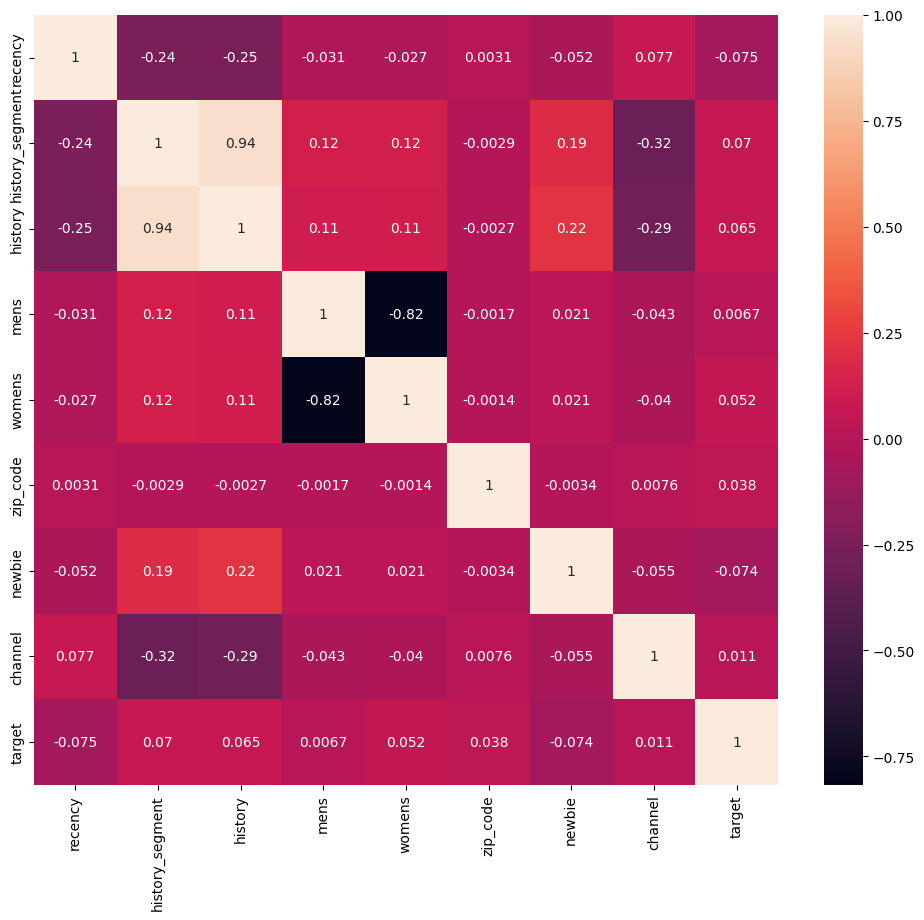

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop('treatment', axis=1).corr(), annot=True)
plt.title('Корреляция признаков')
plt.show()

1. Признаки `history` и `history_segment` имеют полную корреляцию между собой, потому что один признак сделан на основе другого.
2. Признаки `mens` и `womens` имеют отрицательную корреляцию, потому что это просто бинарные признаки и очевидно зачастую один исключает другой.
3. У признака `mens` нет почти никакой корреляции с целевой переменной, из-за чего в принципе можно не рассматривать мужчин как целевую аудиторию.
4. На целевую переменную больше всего влияют признаки `recency`, `history_segment`, `history`, `newbie`, `womens`

## Этап 3

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=df[['target', 'treatment']], test_size=0.2, random_state=42)

### Обучение выбранного бейзлайна

В качестве бейзлайна возьму T-Learner, поскольку группы несбалансированы и эта модель более легковесна по сравнению с остальными.

In [5]:
N_ESTIMATORS = 500
LEARNING_RATE = 0.005
MAX_DEPTH = 6

In [44]:
from causalml.inference.meta import BaseTClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

treatment_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    random_state=42
)
control_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    random_state=42
)

t_learner = BaseTClassifier(
    treatment_learner=treatment_model,
    control_learner=control_model,
    control_name=0,
)

t_learner.fit(
    X=X_train.values,
    treatment=X_train['treatment'].values,
    y=y_train.values
)

t_uplift_pred = t_learner.predict(X_test.values)

### Расчет метрик для выбранного бейзлайна на тестовой выборке

In [11]:
from sklift.metrics import uplift_auc_score, qini_auc_score

def calc_uplift_metrics(y_test, uplift, treatment):
    uplift_score = uplift_auc_score(
        y_test.values,
        uplift,
        treatment.values
    )

    qini_score = qini_auc_score(
        y_test.values,
        uplift,
        treatment.values
    )

    top_n = 30

    top_uplift = np.percentile(uplift, 100 - top_n)

    uplift_30 = np.mean(uplift[uplift >= top_uplift])

    print(f"Uplift AUC: {uplift_score:.4f}")
    print(f"Qini AUC: {qini_score:.4f}")
    print(f"Среднее значение uplift для топ {top_n}% пользователей: {uplift_30:.4f}")

    return {
        'uplift_auc': uplift_score,
        'qini_auc': qini_score,
        'uplift_30': uplift_30
    }

In [58]:
t_metrics = calc_uplift_metrics(y_test, t_uplift_pred.squeeze(), X_test['treatment'])

Uplift AUC: 0.0296
Qini AUC: 0.0665
Среднее значение uplift для топ 30% пользователей: 0.0507


In [60]:
experiment_id = mlflow.set_experiment(EXPERIMENT_NAME).experiment_id

pip_requirements = './requirements.txt'
input_example = X_test.head(10).copy()

with mlflow.start_run(run_name='t_learner', experiment_id=experiment_id) as run:
    mlflow.log_metrics(t_metrics)
    mlflow.sklearn.log_model(
        t_learner,
        pip_requirements=pip_requirements,
        input_example=input_example,
        registered_model_name="uplift_t_learner",
        artifact_path='uplift_yeda'
    )

2026/04/02 20:48:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 20:48:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/mle-user/mle_projects/mle-uplift-yeda/venv/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes m

🏃 View run t_learner at: http://127.0.0.1:5000/#/experiments/7/runs/ccc42ff47ba4417a91e3cb678d5f0f56
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


# Обучение 2 моделей 

### Обучение модели 1

In [52]:
from causalml.inference.meta import BaseRClassifier
from xgboost import XGBClassifier, XGBRegressor
import numpy as np
from sklift.metrics import uplift_auc_score, qini_auc_score

features = df.drop(columns=['target','treatment']).columns
T_train = X_train.treatment.values  # 1 - treatment, 0 - control
X_train_feat = X_train[features]

T_test = X_test.treatment.values
X_test_feat = X_test[features]

r_learner = BaseRClassifier(
    outcome_learner=XGBClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=LEARNING_RATE,
        max_depth=MAX_DEPTH,
        random_state=42,
        verbosity=0
    ),
    effect_learner=XGBRegressor(
        n_estimators=N_ESTIMATORS,
        learning_rate=LEARNING_RATE,
        max_depth=MAX_DEPTH,
        random_state=42,
        verbosity=0
    ),
    propensity_learner=XGBClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=LEARNING_RATE,
        max_depth=MAX_DEPTH,
        random_state=42,
        verbosity=0
    ),
    control_name=0,
)

r_learner.fit(
    X=X_train_feat.values,
    treatment=T_train,
    y=y_train.values,
    verbose=True
)

r_uplift_scores = r_learner.predict(X_test_feat.values)

### Получение метрик по модели 1

In [53]:
r_metrics = calc_uplift_metrics(y_test, r_uplift_scores.squeeze(), X_test.treatment)

Uplift AUC: 0.0228
Qini AUC: 0.0501
Среднее значение uplift для топ 30% пользователей: 0.0564


Довольно хорошие показатели по целевой метрике у R-Learner

In [63]:
experiment_id = mlflow.set_experiment(EXPERIMENT_NAME).experiment_id

pip_requirements = './requirements.txt'
input_example = X_test.head(10).copy()

with mlflow.start_run(run_name='r_learner', experiment_id=experiment_id) as run:
    mlflow.log_metrics(r_metrics)
    mlflow.sklearn.log_model(
        r_learner,
        pip_requirements=pip_requirements,
        input_example=input_example,
        registered_model_name="uplift_r_learner",
        artifact_path='uplift_yeda'
    )

2026/04/02 20:49:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 20:49:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/mle-user/mle_projects/mle-uplift-yeda/venv/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes m

🏃 View run r_learner at: http://127.0.0.1:5000/#/experiments/7/runs/6cf2d6a6438548888d35e66b75dfa4d4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


### Обучение модели 2

In [9]:
from causalml.inference.meta import BaseXClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklift.metrics import uplift_auc_score, qini_auc_score
from xgboost import XGBClassifier, XGBRegressor

rf_clf = XGBClassifier(
    random_state=42,
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    n_jobs=-1,
    verbosity=0
)
rf_reg = XGBRegressor(
    random_state=42,
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    n_jobs=-1,
    verbosity=0
)

# для propensity score используем XGBoost
propensity_model = XGBClassifier(
    random_state=42,
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)
propensity_model.fit(X_train.drop('treatment', axis=1).values, X_train['treatment'].values)
# получаем propensity score для train и test
p_train = propensity_model.predict_proba(X_train.drop('treatment', axis=1).values)[:, 1]
p_test = propensity_model.predict_proba(X_test.drop('treatment', axis=1).values)[:, 1]

x_learner = BaseXClassifier(
    outcome_learner=rf_clf,
    control_name=0,
    effect_learner=rf_reg,
)

# обучаем X-learner с передачей propensity score
x_learner.fit(
    X=X_train.drop('treatment', axis=1).values,
    treatment=X_train['treatment'].values,
    y=y_train.values,
    p=p_train
)

# получаем uplift-предсказания для тестовой выборки, также передаём propensity score
x_uplift_pred = x_learner.predict(
    X_test.drop('treatment', axis=1).values,
    p=p_test
)

### Получение метрик по модели 2

In [10]:
x_metrics = calc_uplift_metrics(y_test, x_uplift_pred.squeeze(), X_test['treatment'])

Uplift AUC: 0.0304
Qini AUC: 0.0680
Среднее значение uplift для топ 30% пользователей: 0.0486


У X-Learner показатели по целевой метрике хуже, хотя по остальным они наоборот выше

In [65]:
experiment_id = mlflow.set_experiment(EXPERIMENT_NAME).experiment_id

pip_requirements = './requirements.txt'
input_example = X_test.head(10).copy()

with mlflow.start_run(run_name='x_learner', experiment_id=experiment_id) as run:
    mlflow.log_metrics(x_metrics)
    mlflow.sklearn.log_model(
        x_learner,
        pip_requirements=pip_requirements,
        input_example=input_example,
        registered_model_name="uplift_x_learner",
        artifact_path='uplift_yeda'
    )

2026/04/02 20:49:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 20:49:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/mle-user/mle_projects/mle-uplift-yeda/venv/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes m

🏃 View run x_learner at: http://127.0.0.1:5000/#/experiments/7/runs/8ed3dedc874942b489bbad22841e1523
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


Среди моделей X-, T-, R-learner лучшие метрики показала модель X-learner. Определяющим стало то что присутсвует несбалансированность групп: контрольная группа в два раза больше тестовой. X-learner использует взвешивание ответов моделей на финальном этапе, что позволяет ему защищаться от смещения в отличие от T-learner и минимизировать ошибку.\
Тем не менее R-learner проиграл по общим метрикам, но выиграл по выборке 30% самых активных пользователей. То есть он смог наиболее точно выделить их среди всех остальных. Если бюджет на рассылку сильно ограничен, то он показал бы наибольшую прибыль среди остальных.\
Но как базовое решение лучше выбрать X-learner, потому что он более стабилен на всей выборке пользователей

# Часть 2

## Этап 1

### Подбор гиперпараметров

Подбор гиперпараметров для X-Learner

In [99]:
from optuna import create_study
from optuna.samplers import TPESampler
from sklift.metrics import uplift_at_k
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import KFold
from causalml.inference.meta import BaseXClassifier
import joblib

STUDY_NAME = 'x-learner-model'
OPTUNA_FOLDER = 'optuna'
DB_FILE_NAME = "optuna_study.db"
STUDY_DB_URI = f'sqlite:///{OPTUNA_FOLDER}/{DB_FILE_NAME}'

def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    X = X_train.drop('treatment', axis=1).reset_index(drop=True)
    T = X_train['treatment'].reset_index(drop=True).values
    Y = y_train.reset_index(drop=True).values

    for train_idx, val_idx in kf.split(X):
        x_tr, x_val = X.iloc[train_idx], X.iloc[val_idx]
        t_tr, t_val = T[train_idx], T[val_idx]
        y_tr, y_val = Y[train_idx], Y[val_idx]
        p_tr, p_val = p_train[train_idx], p_train[val_idx]

        x_learner = BaseXClassifier(
            outcome_learner=XGBClassifier(**param),
            effect_learner=XGBRegressor(**param),
            control_name=0
        )

        x_learner.fit(
            X=x_tr,
            treatment=t_tr,
            y=y_tr,
            p=p_tr
        )

        uplift_pred = x_learner.predict(
            x_val,
            p=p_val
        ).squeeze()

        uplift_at_30 = uplift_at_k(y_val, uplift_pred, t_val, k=0.3, strategy='overall')
        scores.append(uplift_at_30)

    return np.mean(scores)


propensity_model = XGBClassifier(
    random_state=42,
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)
propensity_model.fit(X_train.drop('treatment', axis=1).values, X_train['treatment'].values)
# получаем propensity score для train и test
p_train = propensity_model.predict_proba(X_train.drop('treatment', axis=1).values)[:, 1]
p_test = propensity_model.predict_proba(X_test.drop('treatment', axis=1).values)[:, 1]

joblib.dump(propensity_model, f'{OPTUNA_FOLDER}/propensity_model.pkl')

# Создаем и запускаем исследование
study = create_study(
    direction='maximize', 
    study_name=STUDY_NAME, 
    storage=STUDY_DB_URI,
    load_if_exists=True,
    sampler=TPESampler()
)


[I 2026-04-03 13:46:47,593] Using an existing study with name 'x-learner-model' instead of creating a new one.


In [ ]:
import optuna
from optuna.integration.mlflow import MLflowCallback

experiment_id = mlflow.set_experiment(EXPERIMENT_NAME).experiment_id

parent_run_id = utils.get_or_create_run_id(study, experiment_id, 'x_learner_optuna_param_search')

with mlflow.start_run(run_id=parent_run_id, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    mlflc = MLflowCallback(
        tracking_uri=mlflow.get_tracking_uri(),
        metric_name="uplift_at_30",
        create_experiment=False,
        mlflow_kwargs={
            "experiment_id": experiment_id,
            "nested": True
        }
    )

    study.optimize(objective, n_trials=100, callbacks=[mlflc])

    best_params = study.best_params
    best_params.update({"random_state": 42, "n_jobs": -1})

    # Выводим лучшие гиперпараметры
    print("Best hyperparameters: ", best_params)
    print("Best score: ", study.best_value)

    if optuna.visualization.is_available():
        fig_contour = optuna.visualization.plot_contour(study, params=["max_depth", "learning_rate"])
        fig_contour.write_image(f"{OPTUNA_FOLDER}/plot_contour.png")

        fig_imp = optuna.visualization.plot_param_importances(study)
        fig_imp.write_image(f"{OPTUNA_FOLDER}/param_importance.png")

        fig_opt_history = optuna.visualization.plot_optimization_history(study)
        fig_opt_history.write_image(f"{OPTUNA_FOLDER}/opt_history.png")

        fig_parallel = optuna.visualization.plot_parallel_coordinate(study, params=["n_estimators", "max_depth", "learning_rate"])
        fig_parallel.write_image(f"{OPTUNA_FOLDER}/parallel_coordinate.png")

    best_x_learner = BaseXClassifier(
        outcome_learner=XGBClassifier(**best_params),
        effect_learner=XGBRegressor(**best_params),
        control_name=0
    )

    # обучаем X-learner с передачей propensity score
    best_x_learner.fit(
        X=X_train.drop('treatment', axis=1).values,
        treatment=X_train['treatment'].values,
        y=y_train.values,
        p=p_train
    )

    mlflow.sklearn.log_model(best_x_learner, artifact_path="uplift_yeda", registered_model_name="uplift_x_learner")

    mlflow.log_params(best_params)
    mlflow.log_metric("best_uplift_30", study.best_value)
    mlflow.log_artifacts(OPTUNA_FOLDER)
    mlflow.log_artifact(f"{OPTUNA_FOLDER}/{DB_FILE_NAME}")

/tmp/ipykernel_1565/1191682666.py:11: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlflc = MLflowCallback(
[I 2026-04-03 13:49:00,707] Trial 115 finished with value: 0.03017617921168783 and parameters: {'n_estimators': 814, 'max_depth': 4, 'learning_rate': 0.0029941202373960397}. Best is trial 98 with value: 0.03800217058451445.


🏃 View run 115 at: http://127.0.0.1:5000/#/experiments/7/runs/487befebebe04796ad81bd6eee6b9461
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
Best hyperparameters:  {'n_estimators': 904, 'max_depth': 3, 'learning_rate': 0.004674459762143154, 'random_state': 42, 'n_jobs': -1}
Best score:  0.03800217058451445


2026/04/03 13:49:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 13:49:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'uplift_x_learner' already exists. Creating a new version of this model...
2026/04/03 13:49:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: uplift_x_learner, version 4
Created version '4' of model 'uplift_x_learner'.


🏃 View run x_learner_optuna_param_search at: http://127.0.0.1:5000/#/experiments/7/runs/800397384cb547f5b3c7bfd41d07021a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


Подбор гиперпараметров для R-Learner

In [6]:
from optuna import create_study
from optuna.samplers import TPESampler
from sklift.metrics import uplift_at_k
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import KFold
from causalml.inference.meta import BaseRClassifier
import joblib

STUDY_NAME = 'r_learner_model'
OPTUNA_FOLDER = 'optuna_r'
DB_FILE_NAME = "optuna_study_r.db"
STUDY_DB_URI = f'sqlite:///{OPTUNA_FOLDER}/{DB_FILE_NAME}'

def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    X = X_train.drop('treatment', axis=1).reset_index(drop=True)
    T = X_train['treatment'].reset_index(drop=True).values
    Y = y_train.reset_index(drop=True).values

    for train_idx, val_idx in kf.split(X):
        x_tr, x_val = X.iloc[train_idx], X.iloc[val_idx]
        t_tr, t_val = T[train_idx], T[val_idx]
        y_tr, y_val = Y[train_idx], Y[val_idx]
        p_tr, p_val = p_train[train_idx], p_train[val_idx]

        x_learner = BaseRClassifier(
            outcome_learner=XGBClassifier(**param),
            effect_learner=XGBRegressor(**param),
            control_name=0
        )

        x_learner.fit(
            X=x_tr,
            treatment=t_tr,
            y=y_tr,
            p=p_tr
        )

        uplift_pred = x_learner.predict(x_val).squeeze()

        uplift_at_30 = uplift_at_k(y_val, uplift_pred, t_val, k=0.3, strategy='overall')
        scores.append(uplift_at_30)

    return np.mean(scores)


propensity_model = XGBClassifier(
    random_state=42,
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)
propensity_model.fit(X_train.drop('treatment', axis=1).values, X_train['treatment'].values)
# получаем propensity score для train и test
p_train = propensity_model.predict_proba(X_train.drop('treatment', axis=1).values)[:, 1]
p_test = propensity_model.predict_proba(X_test.drop('treatment', axis=1).values)[:, 1]

joblib.dump(propensity_model, f'{OPTUNA_FOLDER}/propensity_model.pkl')

# Создаем и запускаем исследование
study = create_study(
    direction='maximize', 
    study_name=STUDY_NAME, 
    storage=STUDY_DB_URI,
    load_if_exists=True,
    sampler=TPESampler()
)


[I 2026-04-03 14:30:13,509] Using an existing study with name 'r_learner_model' instead of creating a new one.


In [ ]:
import optuna
from optuna.integration.mlflow import MLflowCallback

experiment_id = mlflow.set_experiment(EXPERIMENT_NAME).experiment_id

parent_run_id = utils.get_or_create_run_id(study, experiment_id, 'r_learner_optuna_param_search')

with mlflow.start_run(run_id=parent_run_id, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    mlflc = MLflowCallback(
        tracking_uri=mlflow.get_tracking_uri(),
        metric_name="uplift_at_30",
        create_experiment=False,
        mlflow_kwargs={
            "experiment_id": experiment_id,
            "nested": True
        }
    )

    study.optimize(objective, n_trials=100, callbacks=[mlflc])

    best_params = study.best_params
    best_params.update({"random_state": 42, "n_jobs": -1})

    # Выводим лучшие гиперпараметры
    print("Best hyperparameters: ", best_params)
    print("Best score: ", study.best_value)

    if optuna.visualization.is_available():
        fig_contour = optuna.visualization.plot_contour(study, params=["max_depth", "learning_rate"])
        fig_contour.write_image(f"{OPTUNA_FOLDER}/plot_contour.png")

        fig_imp = optuna.visualization.plot_param_importances(study)
        fig_imp.write_image(f"{OPTUNA_FOLDER}/param_importance.png")

        fig_opt_history = optuna.visualization.plot_optimization_history(study)
        fig_opt_history.write_image(f"{OPTUNA_FOLDER}/opt_history.png")

        fig_parallel = optuna.visualization.plot_parallel_coordinate(study, params=["n_estimators", "max_depth", "learning_rate", "reg_lambda"])
        fig_parallel.write_image(f"{OPTUNA_FOLDER}/parallel_coordinate.png")

    best_r_learner = BaseRClassifier(
        outcome_learner=XGBClassifier(**best_params),
        effect_learner=XGBRegressor(**best_params),
        control_name=0
    )

    # обучаем X-learner с передачей propensity score
    best_r_learner.fit(
        X=X_train.drop('treatment', axis=1).values,
        treatment=X_train['treatment'].values,
        y=y_train.values,
        p=p_train
    )

    mlflow.sklearn.log_model(best_r_learner, artifact_path="uplift_yeda", registered_model_name="uplift_r_learner")

    mlflow.log_params(best_params)
    mlflow.log_metric("best_uplift_30", study.best_value)
    mlflow.log_artifacts(OPTUNA_FOLDER)
    mlflow.log_artifact(f"{OPTUNA_FOLDER}/{DB_FILE_NAME}")

/tmp/ipykernel_1565/4039835871.py:11: ExperimentalWarning: MLflowCallback is experimental (supported from v1.4.0). The interface can change in the future.
  mlflc = MLflowCallback(
[I 2026-04-03 12:16:48,475] Trial 112 finished with value: 0.02686699031940231 and parameters: {'n_estimators': 802, 'max_depth': 6, 'learning_rate': 0.0023466906875142936, 'reg_lambda': 0.01209887447822663}. Best is trial 39 with value: 0.03918151520446724.


🏃 View run 112 at: http://127.0.0.1:5000/#/experiments/7/runs/01cb012037ef48d2b1b362ba14cab43a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


[I 2026-04-03 12:17:14,295] Trial 113 finished with value: 0.026752977866489176 and parameters: {'n_estimators': 485, 'max_depth': 6, 'learning_rate': 0.004116024738267741, 'reg_lambda': 0.23000327135684204}. Best is trial 39 with value: 0.03918151520446724.


🏃 View run 113 at: http://127.0.0.1:5000/#/experiments/7/runs/74b460c4814e4aa4b206d014b21b1f4a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


[I 2026-04-03 12:17:38,174] Trial 114 finished with value: 0.027145701952493766 and parameters: {'n_estimators': 440, 'max_depth': 6, 'learning_rate': 0.003172045585663856, 'reg_lambda': 0.008000928239984599}. Best is trial 39 with value: 0.03918151520446724.


...

🏃 View run 120 at: http://127.0.0.1:5000/#/experiments/7/runs/d44a5fe94ce140eab65960616f763eab
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


[I 2026-04-03 12:21:02,684] Trial 121 finished with value: 0.026971757833360782 and parameters: {'n_estimators': 509, 'max_depth': 6, 'learning_rate': 0.006257659797428768, 'reg_lambda': 0.002999873887941416}. Best is trial 39 with value: 0.03918151520446724.


🏃 View run 121 at: http://127.0.0.1:5000/#/experiments/7/runs/a5fe3acbd4724eb283d423884285ea8b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
Best hyperparameters:  {'n_estimators': 575, 'max_depth': 3, 'learning_rate': 0.0030462977292448484, 'random_state': 42, 'n_jobs': -1}
Best score:  0.03918151520446724


2026/04/03 12:21:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 12:21:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'uplift_r_learner' already exists. Creating a new version of this model...
2026/04/03 12:21:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: uplift_r_learner, version 5
Created version '5' of model 'uplift_r_learner'.


🏃 View run r_learner_optuna_param_search at: http://127.0.0.1:5000/#/experiments/7/runs/7284dd5a59ff45fc8293e2464f369398
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


## Этап 2

### Визуализация результатов

In [16]:
from utils import custom_uplift_by_percentile

FINAL_PLOTS_DIR = 'final_plots'

Сравнение метрик лучших R-Learner и X-Learner

In [12]:
uplift_r_preds = best_r_learner.predict(X_test.drop('treatment', axis=1).values).squeeze()
r_metrics = calc_uplift_metrics(y_test, uplift_r_preds.squeeze(), X_test['treatment'])

Uplift AUC: 0.0303
Qini AUC: 0.0674
Среднее значение uplift для топ 30% пользователей: 0.0387


In [ ]:
uplift_preds = best_x_learner.predict(X_test.drop('treatment', axis=1).values, p=p_test).squeeze()
metrics = calc_uplift_metrics(y_test, uplift_preds.squeeze(), X_test['treatment'])

Uplift AUC: 0.0291
Qini AUC: 0.0649
Среднее значение uplift для топ 30% пользователей: 0.0436


X-Learner лучше по метрике `Uplift@30`, так что он больше подходит под задачу

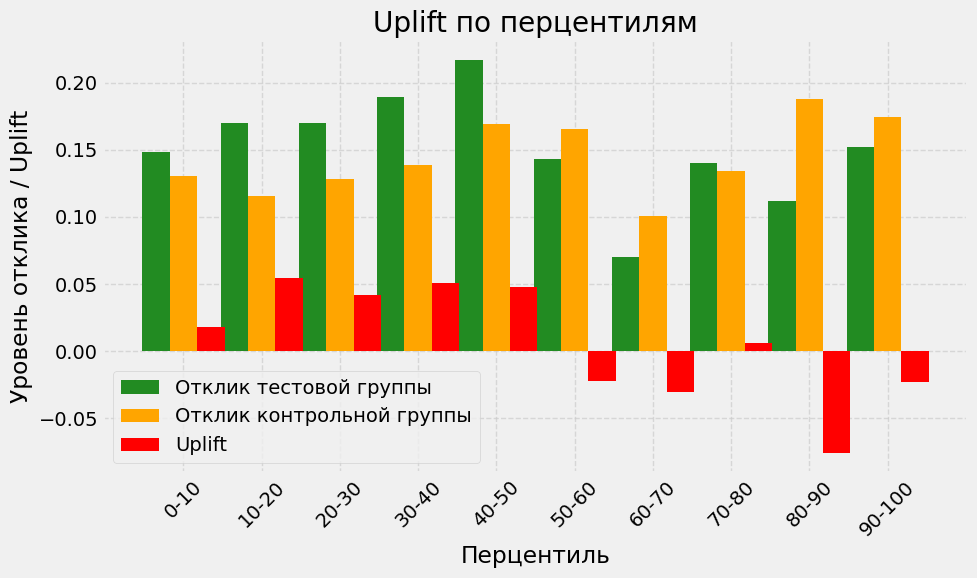

In [79]:
fig = custom_uplift_by_percentile(
    y_test,
    uplift_preds,
    X_test['treatment'],
    kind='bar',
    bins=10,
    title='Uplift по перцентилям'
)
fig.savefig(f"{FINAL_PLOTS_DIR}/uplift_by_percentile.png")
plt.show()

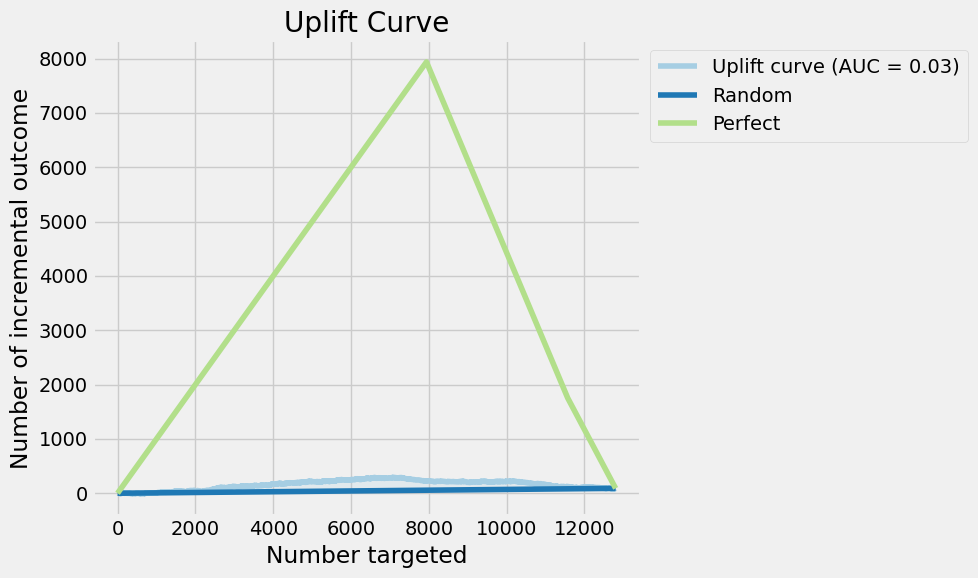

In [80]:
from sklift.viz import plot_uplift_curve

fig, axs = plt.subplots(1, 1, figsize=(10, 6))

plot_uplift_curve(y_test, uplift_preds, X_test['treatment'], ax=axs, perfect=True, name='Uplift curve')
axs.set_title('Uplift Curve')
axs.grid(True)
plt.tight_layout()
plt.savefig(f"{FINAL_PLOTS_DIR}/uplift_curve.png")
plt.show()

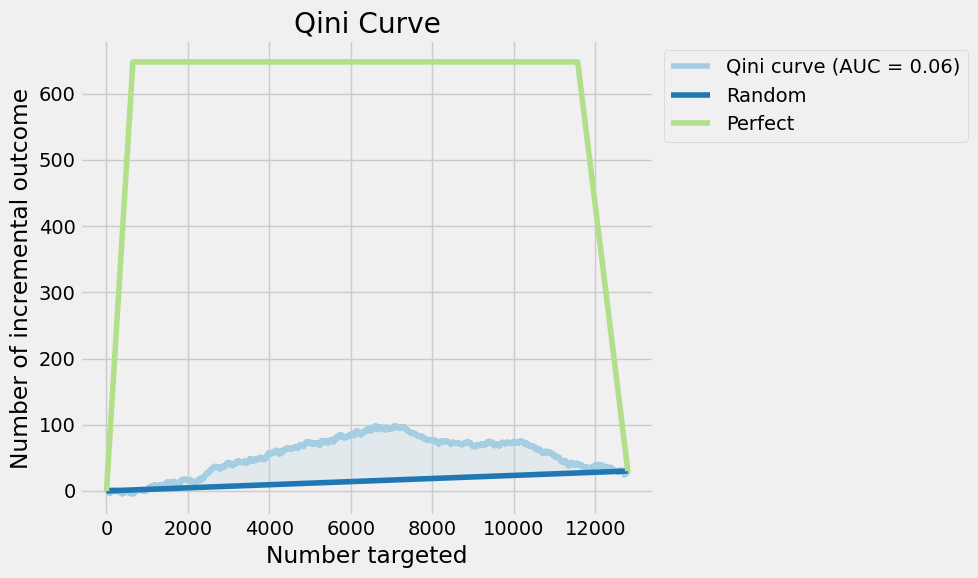

In [81]:
from sklift.viz import plot_qini_curve

fig, axs = plt.subplots(1, 1, figsize=(10, 6))

plot_qini_curve(y_test, uplift_preds, X_test['treatment'], ax=axs, perfect=True, name='Qini curve')
axs.set_title('Qini Curve')
axs.grid(True)
plt.tight_layout()
plt.savefig(f"{FINAL_PLOTS_DIR}/qini_curve.png")
plt.show()

На графике `uplift by percentile` можно заметить что после 50-го персентиля uplift становится отрицательным, что свидетельствует о способности модели выявлять "спящих собак", на которых воздействие окажет отрицательный эффект. 

По метрикам uplift AUC и Qini AUC R-Learner показывает себя достойно, покрывая всех пользователей. Но по метрике `Uplift@30` он находится лишь на уровне удовлетворительно. Стоит заметить, что для R-Learner при первом ручном обучении она была равна `0.0564`, а при оптимизации на кросс-валидации упала до `0.0388`, что должно быть более правдивым результатом. Основное различие в параметре `max_depth`, который вручную был выбран 6, а optuna посчитала его неважным и стала эксплуатировать значение 3. На разных фолдах мог быть большой разброс по данной метрике, а optuna выбирает параметры, которые дают стабильный результат на всех фолдах и глубина 3 оказалась более надежной.

X-Learner после обучения на кросс-валидации показал `0.0436`, и несмотря на то, что он ниже по метрикам Uplift AUC и Qini AUC, в рамках поставленной задачи целевая метрика у него выше после оптимизации гиперпараметров, так что он может быть выбран как итоговая модель.

# Этап 3

In [110]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, propensity_model, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model

        if not propensity_model:
            raise ValueError("Propensity model is None")

        self.propensity_model = propensity_model

        if not feature_names:
            self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        else:
            self.feature_names = feature_names

        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", self.feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        
        try:
            p_score = self.propensity_model.predict_proba(X)[:,1]
            uplift = self.model.predict(X.values, p=p_score).squeeze()
            if self.logger:
                self.logger.info("Предсказания успешно завершены")
        except Exception as e:
            uplift = [None]*len(X)
            if self.logger:
                self.logger.error(f"Ошибка предсказания uplift: {e}")
        
        return uplift


In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

model_name = "uplift_x_learner"
version = 4

client.transition_model_version_stage(
    name=model_name,
    version=version,
    stage="Production",
    archive_existing_versions=True
)

model_version_details = client.get_model_version(name=model_name, version=version)
run_id = model_version_details.run_id

model_uri = f"models:/{model_name}/Production"

local_path = mlflow.artifacts.download_artifacts(model_uri, dst_path='./models/uplift_model')

p_model_path = client.download_artifacts(run_id, "propensity_model.pkl")
p_model = joblib.load(p_model_path)

/tmp/ipykernel_1565/4111827933.py:8: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


In [111]:
import joblib
import logging

logger = logging.getLogger("error")

with open('models/uplift_model/model.pkl', 'rb') as f:
    prod_model = joblib.load(f)

feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']

model = UpliftModelInference(model=prod_model,
                             feature_names=feature_names,
                             propensity_model=propensity_model,
                             logger=logger)

In [89]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [112]:
# проверка работы класса
model.predict(test_data)

array([-0.02762248,  0.01419197, -0.02671212])